<a href="https://colab.research.google.com/github/JuliMiralles/Diplomatura-en-An-lisis-Cuantitativo-y-Machine-Learning-aplicado-al-Riesgo-Financiero/blob/main/Modulo1_Clase2_Volatilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 1 · Clase 2 — Factores de riesgo, retornos y volatilidad
## Notebook de trabajo

Diplomatura en Análisis Cuantitativo y Machine Learning aplicado al Riesgo Financiero  
**Universidad Austral — Sede Rosario**  
Dr. Rodrigo Del Rosso — Director Académico

---

**Cartera del curso**

| Instrumento | Factor de riesgo | Peso |
|---|---|---|
| SPY | Precio de acciones (EE.UU.) | 40 % |
| TLT | Curva soberana larga | 30 % |
| GLD | Oro | 20 % |
| EURUSD | Tipo de cambio | 10 % |

Este mismo objeto se reutiliza íntegramente en la Clase 3.

**Cómo usar el notebook.** Ejecutá las celdas en orden. Las marcadas con **✏️ Consigna**
requieren que escribas código o texto: son las que se evalúan.


## Bloque 0 · Configuración

In [ ]:
# Configuración del entorno
!pip -q install yfinance arch statsmodels --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEMILLA = 20260901
rng = np.random.default_rng(SEMILLA)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 3.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

# Paleta institucional (tomada de la identidad visual de la Universidad Austral)
AZUL, CELESTE, NARANJA, VINO = "#1A25AB", "#67A0D5", "#EB7D0C", "#771C2D"
ROJO, GRIS = "#C41230", "#9A9A9A"
COLORES = {"SPY": AZUL, "TLT": CELESTE, "GLD": NARANJA, "EURUSD": VINO}

import sys
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.3 MB/s eta 0:00:00
Python 3.13.15 | numpy 2.1.3 | pandas 2.2.3


## Bloque 1 · Datos de mercado

### 1.1 Descarga y saneamiento

Cada decisión de esta celda modifica los momentos estimados. Están aisladas y
documentadas a propósito, para que el efecto de cambiarlas sea medible.

In [ ]:
import yfinance as yf

TICKERS = ["SPY", "TLT", "GLD", "EURUSD=X"]
NOMBRES = ["SPY", "TLT", "GLD", "EURUSD"]
INICIO, FIN = "2021-03-01", "2026-03-01"

raw = yf.download(TICKERS, start=INICIO, end=FIN, auto_adjust=True, progress=False)["Close"]
raw = raw[TICKERS]
raw.columns = NOMBRES

print("Filas descargadas:", len(raw))
print("Faltantes por columna:\n", raw.isna().sum(), sep="")

# Intersección de calendarios: se descarta la fecha si falta algún instrumento.
# Alternativa (NO recomendada): raw.ffill(), que imputa retornos nulos.
px = raw.dropna(how="any").copy()
print(f"\nFechas conservadas: {len(px)} de {len(raw)} ({len(px)/len(raw):.1%})")
px.tail()

Filas descargadas: 1301
Faltantes por columna:
SPY       45
TLT       45
GLD       45
EURUSD     1
dtype: int64

Fechas conservadas: 1255 de 1301 (96.5%)


,SPY,TLT,GLD,EURUSD
Date,,,,
2026-02-23,678.7828,87.7324,481.2800,1.1835
2026-02-24,683.7165,87.8888,474.6100,1.1794
2026-02-25,689.4859,87.8986,473.4200,1.1775
2026-02-26,685.6562,88.2505,477.4800,1.1815
2026-02-27,682.3637,88.7882,483.7500,1.1803


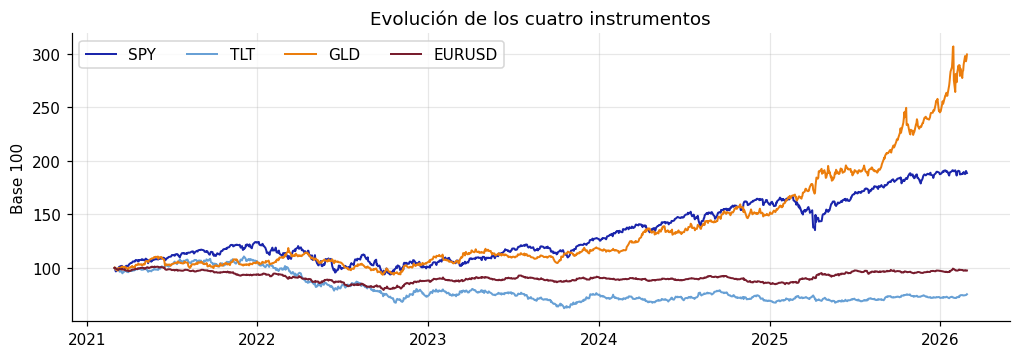

In [ ]:
PESOS = pd.Series({"SPY": 0.40, "TLT": 0.30, "GLD": 0.20, "EURUSD": 0.10})
assert np.isclose(PESOS.sum(), 1.0), "Los pesos deben sumar 1"

fig, ax = plt.subplots()
base = px / px.iloc[0] * 100
for a in px.columns:
    ax.plot(base.index, base[a], color=COLORES[a], lw=1.3, label=a)
ax.set_ylabel("Base 100")
ax.set_title("Evolución de los cuatro instrumentos")
ax.legend(ncol=4)
plt.show()

### 1.2 Retornos y verificaciones

In [ ]:
ret = np.log(px / px.shift(1)).dropna()

# ---- Control 2 · dimensional y de rango -------------------------------------
assert ret.notna().all().all(), "Hay valores faltantes en los retornos"
extremos = (ret.abs() > 0.25).sum()
print("Retornos con |r| > 25 % (revisar uno por uno si son > 0):\n", extremos, sep="")

huecos = ret.index.to_series().diff().dt.days.max()
print(f"\nHueco máximo en el índice: {huecos:.0f} días corridos")
print(f"Período: {ret.index.min():%Y-%m-%d} a {ret.index.max():%Y-%m-%d}  ({len(ret)} ruedas)")

ret.describe().T[["mean", "std", "min", "max"]]

Retornos con |r| > 25 % (revisar uno por uno si son > 0):
SPY       0
TLT       0
GLD       0
EURUSD    0
dtype: int64

Hueco máximo en el índice: 5 días corridos
Período: 2021-03-02 a 2026-02-27  (1254 ruedas)


,mean,std,min,max
SPY,0.0005,0.0106,-0.0603,0.0999
TLT,-0.0002,0.0100,-0.0348,0.0378
GLD,0.0009,0.0108,-0.1084,0.0616
EURUSD,-0.0000,0.0048,-0.0186,0.0275


In [ ]:
desc = pd.DataFrame({
    "μ anual (%)": ret.mean() * 252 * 100,
    "σ anual (%)": ret.std(ddof=1) * np.sqrt(252) * 100,
    "Asimetría":   ret.apply(stats.skew),
    "Curtosis":    ret.apply(lambda x: stats.kurtosis(x, fisher=False)),
})
display(desc.style.format("{:.2f}"))

print("Curtosis de la normal = 3. Todo valor por encima indica colas más pesadas.")

,μ anual (%),σ anual (%),Asimetría,Curtosis
SPY,12.75,16.91,0.14,11.42
TLT,-5.67,15.91,-0.01,3.44
GLD,22.04,17.13,-0.94,13.77
EURUSD,-0.48,7.62,0.17,4.84


Curtosis de la normal = 3. Todo valor por encima indica colas más pesadas.


### ✏️ Consigna 1 — Extensión del panel

Incorporá un **quinto instrumento** que represente un factor no cubierto por la cartera
actual. Opciones sugeridas: `LQD` o `HYG` (spread crediticio), `EEM` (acciones emergentes),
`DBA` (commodities agrícolas).

Justificá en dos líneas qué factor agrega y por qué.

In [ ]:
# TU CÓDIGO ACÁ
# TICKER_5 = "LQD"
# ...

# Justificación (dos líneas):
# 1.
# 2.

## Bloque 2 · Contraste de los hechos estilizados

Cada hecho enunciado en la Clase 1 se somete acá a un contraste formal.

### 2.1 Hechos 1 y 3 — Autocorrelación del nivel y de la magnitud

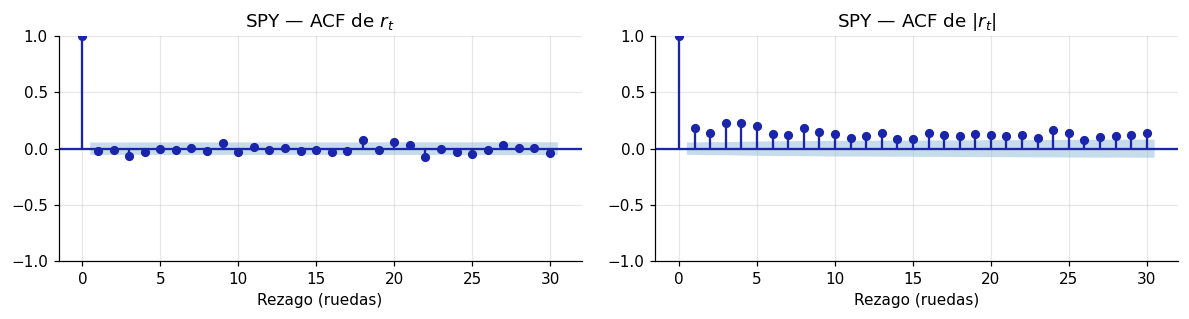

Q(10) sobre r  :    13.15   p = 0.2152
Q(10) sobre r² :   233.58   p = 0.0000

Lectura esperada: no rechazar en r (media impredecible),
rechazar con contundencia en r² (volatilidad predecible).


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

ACTIVO = "SPY"
serie = ret[ACTIVO]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
plot_acf(serie, lags=30, ax=axes[0], color=AZUL, vlines_kwargs={"colors": AZUL})
axes[0].set_title(f"{ACTIVO} — ACF de $r_t$")
plot_acf(serie.abs(), lags=30, ax=axes[1], color=AZUL, vlines_kwargs={"colors": AZUL})
axes[1].set_title(f"{ACTIVO} — ACF de $|r_t|$")
for ax in axes:
    ax.set_xlabel("Rezago (ruedas)")
plt.tight_layout(); plt.show()

q_r  = acorr_ljungbox(serie,      lags=[10], return_df=True)
q_r2 = acorr_ljungbox(serie ** 2, lags=[10], return_df=True)
print(f"Q(10) sobre r  : {q_r['lb_stat'].iloc[0]:8.2f}   p = {q_r['lb_pvalue'].iloc[0]:.4f}")
print(f"Q(10) sobre r² : {q_r2['lb_stat'].iloc[0]:8.2f}   p = {q_r2['lb_pvalue'].iloc[0]:.4f}")
print("\nLectura esperada: no rechazar en r (media impredecible),")
print("rechazar con contundencia en r² (volatilidad predecible).")

### 2.2 Hecho 2 — Colas pesadas

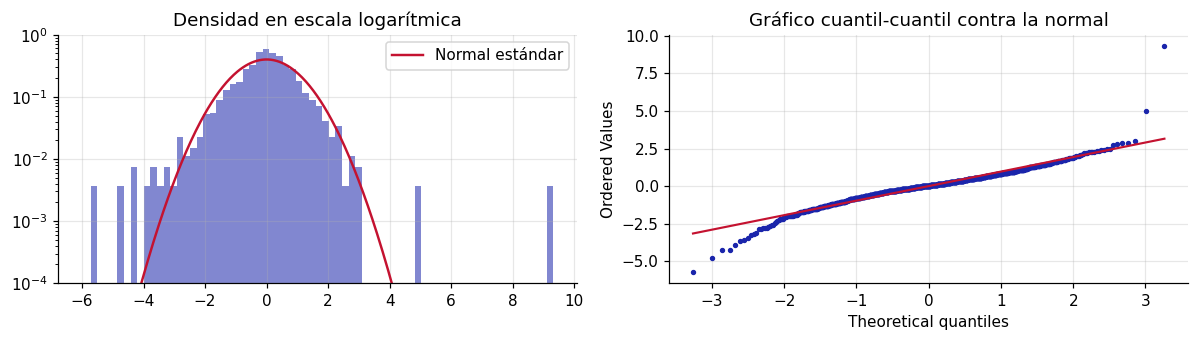

Curtosis   : 11.42   (normal = 3)
Jarque-Bera: 3,709.1   p = 0


In [ ]:
z = (serie - serie.mean()) / serie.std(ddof=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

axes[0].hist(z, bins=70, density=True, color=AZUL, alpha=0.55)
xs = np.linspace(-6, 6, 400)
axes[0].plot(xs, stats.norm.pdf(xs), color=ROJO, lw=1.6, label="Normal estándar")
axes[0].set_yscale("log"); axes[0].set_ylim(1e-4, 1)
axes[0].set_title("Densidad en escala logarítmica"); axes[0].legend()

stats.probplot(z, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(color=AZUL, markersize=2.5)
axes[1].get_lines()[1].set(color=ROJO, lw=1.4)
axes[1].set_title("Gráfico cuantil-cuantil contra la normal")
plt.tight_layout(); plt.show()

jb, p = stats.jarque_bera(serie)
print(f"Curtosis   : {stats.kurtosis(serie, fisher=False):.2f}   (normal = 3)")
print(f"Jarque-Bera: {jb:,.1f}   p = {p:.3g}")

> **Advertencia metodológica.** Con más de mil observaciones casi cualquier desviación
> de la normalidad resulta significativa. El valor p informa si la desviación existe, no si
> es económicamente relevante. Para riesgo importa la **magnitud** del exceso de curtosis.

### 2.3 Hechos 4 y 5 — Asimetría y efecto apalancamiento

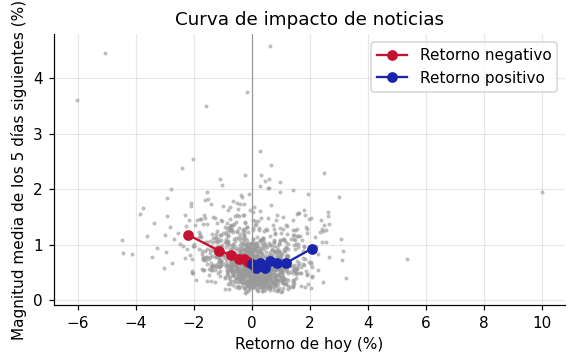

Tras caídas fuertes : 0.96 %
Tras subas fuertes  : 0.76 %
Cociente            : 1.27   (> 1 indica efecto apalancamiento)


In [ ]:
# Curva de impacto de noticias: magnitud esperada del movimiento siguiente
r_pct = serie * 100
fwd = r_pct.abs().rolling(5).mean().shift(-5)
d = pd.concat([r_pct.rename("hoy"), fwd.rename("prox")], axis=1).dropna()

cortes = np.quantile(d["hoy"], np.linspace(0, 1, 15))
d["bin"] = np.digitize(d["hoy"], cortes[1:-1])
g = d.groupby("bin").agg(x=("hoy", "mean"), y=("prox", "mean"))

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.scatter(d["hoy"], d["prox"], s=3, color=GRIS, alpha=0.5)
neg = g["x"] < 0
ax.plot(g.loc[neg, "x"], g.loc[neg, "y"], "o-", color=ROJO, label="Retorno negativo")
ax.plot(g.loc[~neg, "x"], g.loc[~neg, "y"], "o-", color=AZUL, label="Retorno positivo")
ax.axvline(0, color=GRIS, lw=0.8)
ax.set_xlabel("Retorno de hoy (%)")
ax.set_ylabel("Magnitud media de los 5 días siguientes (%)")
ax.set_title("Curva de impacto de noticias")
ax.legend(); plt.show()

izq, der = g.loc[neg, "y"].head(3).mean(), g.loc[~neg, "y"].tail(3).mean()
print(f"Tras caídas fuertes : {izq:.2f} %")
print(f"Tras subas fuertes  : {der:.2f} %")
print(f"Cociente            : {izq/der:.2f}   (> 1 indica efecto apalancamiento)")

### 2.4 Hecho 6 — Normalidad agregada

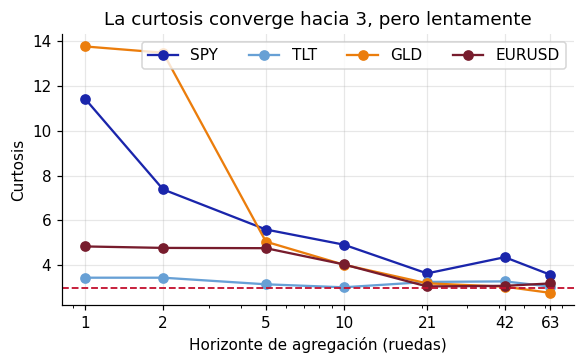

,SPY,TLT,GLD,EURUSD
1,11.42,3.44,13.77,4.84
2,7.39,3.44,13.49,4.77
5,5.60,3.15,5.05,4.76
10,4.92,3.01,4.02,4.04
21,3.63,3.25,3.19,3.05
42,4.36,3.28,3.04,3.08
63,3.57,3.05,2.77,3.19


In [ ]:
hs = [1, 2, 5, 10, 21, 42, 63]
k = pd.DataFrame({a: [stats.kurtosis(ret[a].rolling(h).sum().dropna(), fisher=False)
                      for h in hs] for a in ret.columns}, index=hs)

fig, ax = plt.subplots(figsize=(6, 3.2))
for a in ret.columns:
    ax.plot(k.index, k[a], "o-", color=COLORES[a], label=a)
ax.axhline(3, color=ROJO, ls="--", lw=1.2)
ax.set_xscale("log"); ax.set_xticks(hs); ax.set_xticklabels(hs)
ax.set_xlabel("Horizonte de agregación (ruedas)"); ax.set_ylabel("Curtosis")
ax.set_title("La curtosis converge hacia 3, pero lentamente")
ax.legend(ncol=4); plt.show()
display(k.style.format("{:.2f}"))

### ✏️ Consigna 2 — Contraste completo

Aplicá la batería anterior a **los cinco activos** y construí una única tabla comparativa
con asimetría, curtosis, Jarque-Bera y Ljung-Box sobre $r_t$ y $r_t^2$.

Identificá cuál se aparta más de la normalidad y cuál menos.

In [ ]:
# TU CÓDIGO ACÁ
# Sugerencia: recorrer las columnas y armar una lista de diccionarios,
# luego pd.DataFrame(filas).set_index("activo")

## Bloque 3 · Estimación de volatilidad

### 3.1 Ventana móvil y el compromiso de la ventana

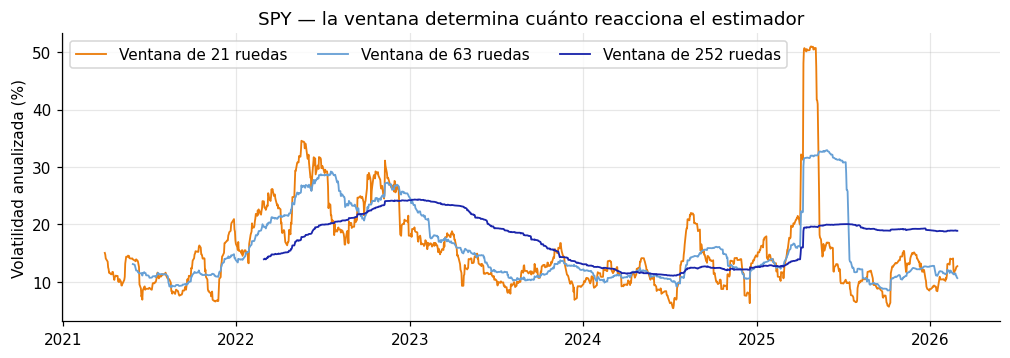

Ventana corta: reacciona rápido pero es ruidosa.
Ventana larga: estable pero tarda meses en incorporar y en olvidar un cambio.


In [ ]:
fig, ax = plt.subplots()
for w, c in [(21, NARANJA), (63, CELESTE), (252, AZUL)]:
    v = serie.rolling(w).std(ddof=1) * np.sqrt(252) * 100
    ax.plot(v.index, v, color=c, lw=1.2, label=f"Ventana de {w} ruedas")
ax.set_ylabel("Volatilidad anualizada (%)")
ax.set_title(f"{ACTIVO} — la ventana determina cuánto reacciona el estimador")
ax.legend(ncol=3); plt.show()

print("Ventana corta: reacciona rápido pero es ruidosa.")
print("Ventana larga: estable pero tarda meses en incorporar y en olvidar un cambio.")

### 3.2 EWMA

$$\sigma_t^2 = \lambda\,\sigma_{t-1}^2 + (1-\lambda)\,r_{t-1}^2
= (1-\lambda)\sum_{j\ge 0}\lambda^{\,j} r_{t-1-j}^2$$

Vida media del ponderador: $h_{1/2} = \ln(0{,}5)/\ln\lambda \approx 11$ ruedas para $\lambda = 0{,}94$.

Correlación entre ambas implementaciones: 0.999947


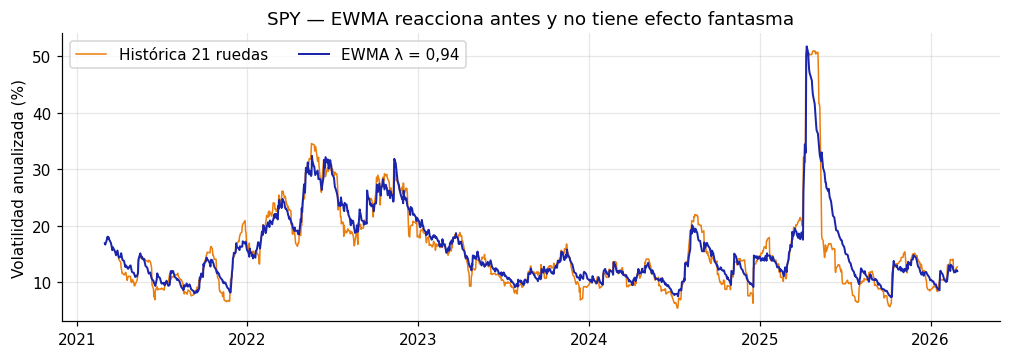


Vida media del ponderador: 11.2 ruedas


In [ ]:
def ewma_vol(r, lam=0.94, anual=252):
    """Volatilidad EWMA anualizada. Inicializa con la varianza muestral completa."""
    x = np.asarray(r, dtype=float)
    s2 = np.empty(len(x)); s2[0] = x.var(ddof=1)
    for t in range(1, len(x)):
        s2[t] = lam * s2[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(np.sqrt(s2 * anual), index=r.index)

ew = ewma_vol(serie)

# ---- Control 1 · numerico: comparar contra la implementacion de pandas ------
alt = np.sqrt(serie.shift(1).pow(2).ewm(alpha=1 - 0.94, adjust=False).mean() * 252)
print("Correlación entre ambas implementaciones:",
      round(ew.iloc[30:].corr(alt.iloc[30:]), 6))

vh = serie.rolling(21).std(ddof=1) * np.sqrt(252)
fig, ax = plt.subplots()
ax.plot(vh.index, vh * 100, color=NARANJA, lw=1.0, label="Histórica 21 ruedas")
ax.plot(ew.index, ew * 100, color=AZUL, lw=1.3, label="EWMA λ = 0,94")
ax.set_ylabel("Volatilidad anualizada (%)")
ax.set_title(f"{ACTIVO} — EWMA reacciona antes y no tiene efecto fantasma")
ax.legend(ncol=2); plt.show()

print(f"\nVida media del ponderador: {np.log(0.5)/np.log(0.94):.1f} ruedas")

### ✏️ Consigna 3 — Sensibilidad al parámetro

Estimá la volatilidad EWMA para $\lambda \in \{0{,}90;\ 0{,}94;\ 0{,}97\}$ y ventanas móviles
de 21, 63 y 252 ruedas. Graficá las seis series y argumentá cuál usarías para fijar un
**límite de riesgo diario**, justificando el criterio.

In [ ]:
# TU CÓDIGO ACÁ

## Bloque 4 · De los activos a la cartera

### 4.1 Matriz de covarianzas

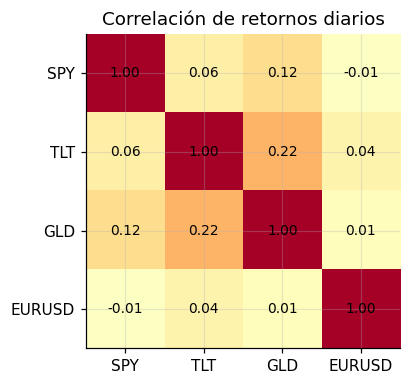

In [ ]:
SIGMA = ret.cov().values * 252          # anualizada
CORR = ret.corr()

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(CORR.values, cmap="RdYlBu_r", vmin=-0.6, vmax=0.6)
ax.set_xticks(range(4)); ax.set_xticklabels(CORR.columns)
ax.set_yticks(range(4)); ax.set_yticklabels(CORR.index)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{CORR.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Correlación de retornos diarios")
plt.tight_layout(); plt.show()

### 4.2 Volatilidad de cartera y contribución al riesgo

$$\sigma_p=\sqrt{\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}},\qquad
\mathrm{MCR}_i=\frac{(\boldsymbol{\Sigma}\mathbf{w})_i}{\sigma_p},\qquad
\mathrm{CCR}_i=w_i\,\mathrm{MCR}_i,\qquad \sum_i \mathrm{CCR}_i=\sigma_p$$

Control numérico superado: Σ CCR = 0.099036 = σ_p


,Peso %,σ individual %,CCR %
SPY,40.00,16.91,51.51
TLT,30.00,15.91,29.11
GLD,20.00,17.13,18.63
EURUSD,10.00,7.62,0.75



Volatilidad de la cartera        : 9.90%
Promedio ponderado de σ individual: 15.72%
La diferencia entre ambos números es, exactamente, la diversificación.


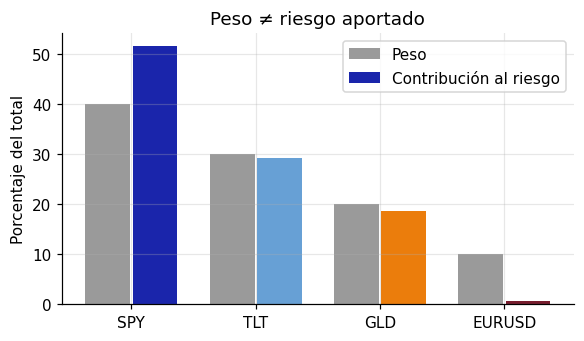

In [ ]:
w = PESOS.values
sigma_p = float(np.sqrt(w @ SIGMA @ w))
mcr = (SIGMA @ w) / sigma_p
ccr = w * mcr

# ---- Control 1 · numerico: la descomposicion debe ser exacta ---------------
assert np.isclose(ccr.sum(), sigma_p), "Las contribuciones no suman sigma_p"
print(f"Control numérico superado: Σ CCR = {ccr.sum():.6f} = σ_p")

res = pd.DataFrame({"Peso %": w * 100,
                    "σ individual %": np.sqrt(np.diag(SIGMA)) * 100,
                    "CCR %": ccr / sigma_p * 100}, index=PESOS.index)
display(res.style.format("{:.2f}"))

print(f"\nVolatilidad de la cartera        : {sigma_p:.2%}")
print(f"Promedio ponderado de σ individual: {(w * np.sqrt(np.diag(SIGMA))).sum():.2%}")
print("La diferencia entre ambos números es, exactamente, la diversificación.")

fig, ax = plt.subplots(figsize=(6, 3.2))
x = np.arange(4)
ax.bar(x - 0.19, res["Peso %"], 0.36, color=GRIS, label="Peso")
ax.bar(x + 0.19, res["CCR %"], 0.36, color=[COLORES[a] for a in res.index],
       label="Contribución al riesgo")
ax.set_xticks(x); ax.set_xticklabels(res.index)
ax.set_ylabel("Porcentaje del total"); ax.set_title("Peso ≠ riesgo aportado")
ax.legend(); plt.show()

### 4.3 Mapeo de sensibilidades

In [ ]:
V0 = 10_000_000                     # valor de la cartera en USD
delta = V0 * w                      # exposicion en dolares por factor
sigma_V = float(np.sqrt(delta @ SIGMA @ delta))

print("Exposición por factor (USD):")
for a, d in zip(PESOS.index, delta):
    print(f"  {a:<7} {d:>12,.0f}")
print(f"\nVolatilidad anual de la cartera: {sigma_V:,.0f} USD  ({sigma_V/V0:.2%})")

# Objeto que se reutiliza en la Clase 3
np.savez("cartera_modulo1.npz", delta=delta, SIGMA=SIGMA, w=w, V0=V0,
         activos=np.array(list(PESOS.index)))
ret.to_csv("retornos_modulo1.csv")
print("\nGuardado: cartera_modulo1.npz y retornos_modulo1.csv")

Exposición por factor (USD):
  SPY        4,000,000
  TLT        3,000,000
  GLD        2,000,000
  EURUSD     1,000,000

Volatilidad anual de la cartera: 990,360 USD  (9.90%)

Guardado: cartera_modulo1.npz y retornos_modulo1.csv


### ✏️ Consigna 4 — Descomposición

Calculá $\sigma_p$ y la contribución al riesgo con **los pesos que vos propongas**.
Después encontrá el vector de pesos que **iguala las contribuciones** (paridad de riesgo)
y compará su volatilidad con la de la cartera original.

*Pista:* usá `scipy.optimize.minimize` sobre la suma de cuadrados de las diferencias
entre cada CCR y su promedio, con las restricciones $\sum w_i = 1$ y $w_i \ge 0$.

In [ ]:
# TU CÓDIGO ACÁ
# from scipy.optimize import minimize

## Bloque 5 · Verificación asistida por IA

### ✏️ Consigna 5

Elegí uno de los cálculos anteriores, resolvelo con asistencia de IA y documentá:

1. **El prompt completo** que utilizaste, con sus cinco componentes: contexto, tarea,
   restricciones, verificación y supuestos.
2. **Control numérico** — cómo reprodujiste el resultado por una vía independiente.
3. **Control dimensional y de rango** — qué unidades y qué rango de plausibilidad verificaste.
4. **Control de supuestos** — qué supone el procedimiento y si los datos lo sostienen.

---

**Plantilla de prompt**

```
# CONTEXTO
Trabajo con un DataFrame `ret` de retornos logarítmicos diarios,
índice DatetimeIndex, columnas SPY, TLT, GLD, EURUSD, n = ...

# TAREA
...

# RESTRICCIONES
Solo numpy y pandas. Devuelve volatilidad anualizada con 252 ruedas.

# VERIFICACIÓN
Incluye un test que compare tu salida contra el cálculo explícito.

# SUPUESTOS
Enumera los supuestos que hace tu implementación.
```

In [ ]:
# TU CÓDIGO ACÁ, con los tres controles documentados en comentarios

---

## Cierre

La **Clase 3** parte exactamente del par `(delta, SIGMA)` que quedó guardado en
`cartera_modulo1.npz`. Descargá ese archivo o dejá el notebook en tu Drive.

**Lectura obligatoria:** Christoffersen (2012), caps. 1 y 2; Danielsson (2011), caps. 4 y 5.